In [4]:
#Import neccessary libraries
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
# Set column names
operational_settings = [f'operational_setting_{i}' for i in range(1, 4)]
sensor_measurements = [f'sensor_measurement_{i}' for i in range(1, 22)]
cols = ['unit_number', 'time_in_cycles'] + operational_settings + sensor_measurements

In [13]:
# Load data
train_001 = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=cols)
train_001.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [14]:
# Compute Remaining Useful Life (RUL)
train_001['max_cycle'] = train_001.groupby('unit_number')['time_in_cycles'].transform('max')
train_001['RUL'] = train_001['max_cycle'] - train_001['time_in_cycles']

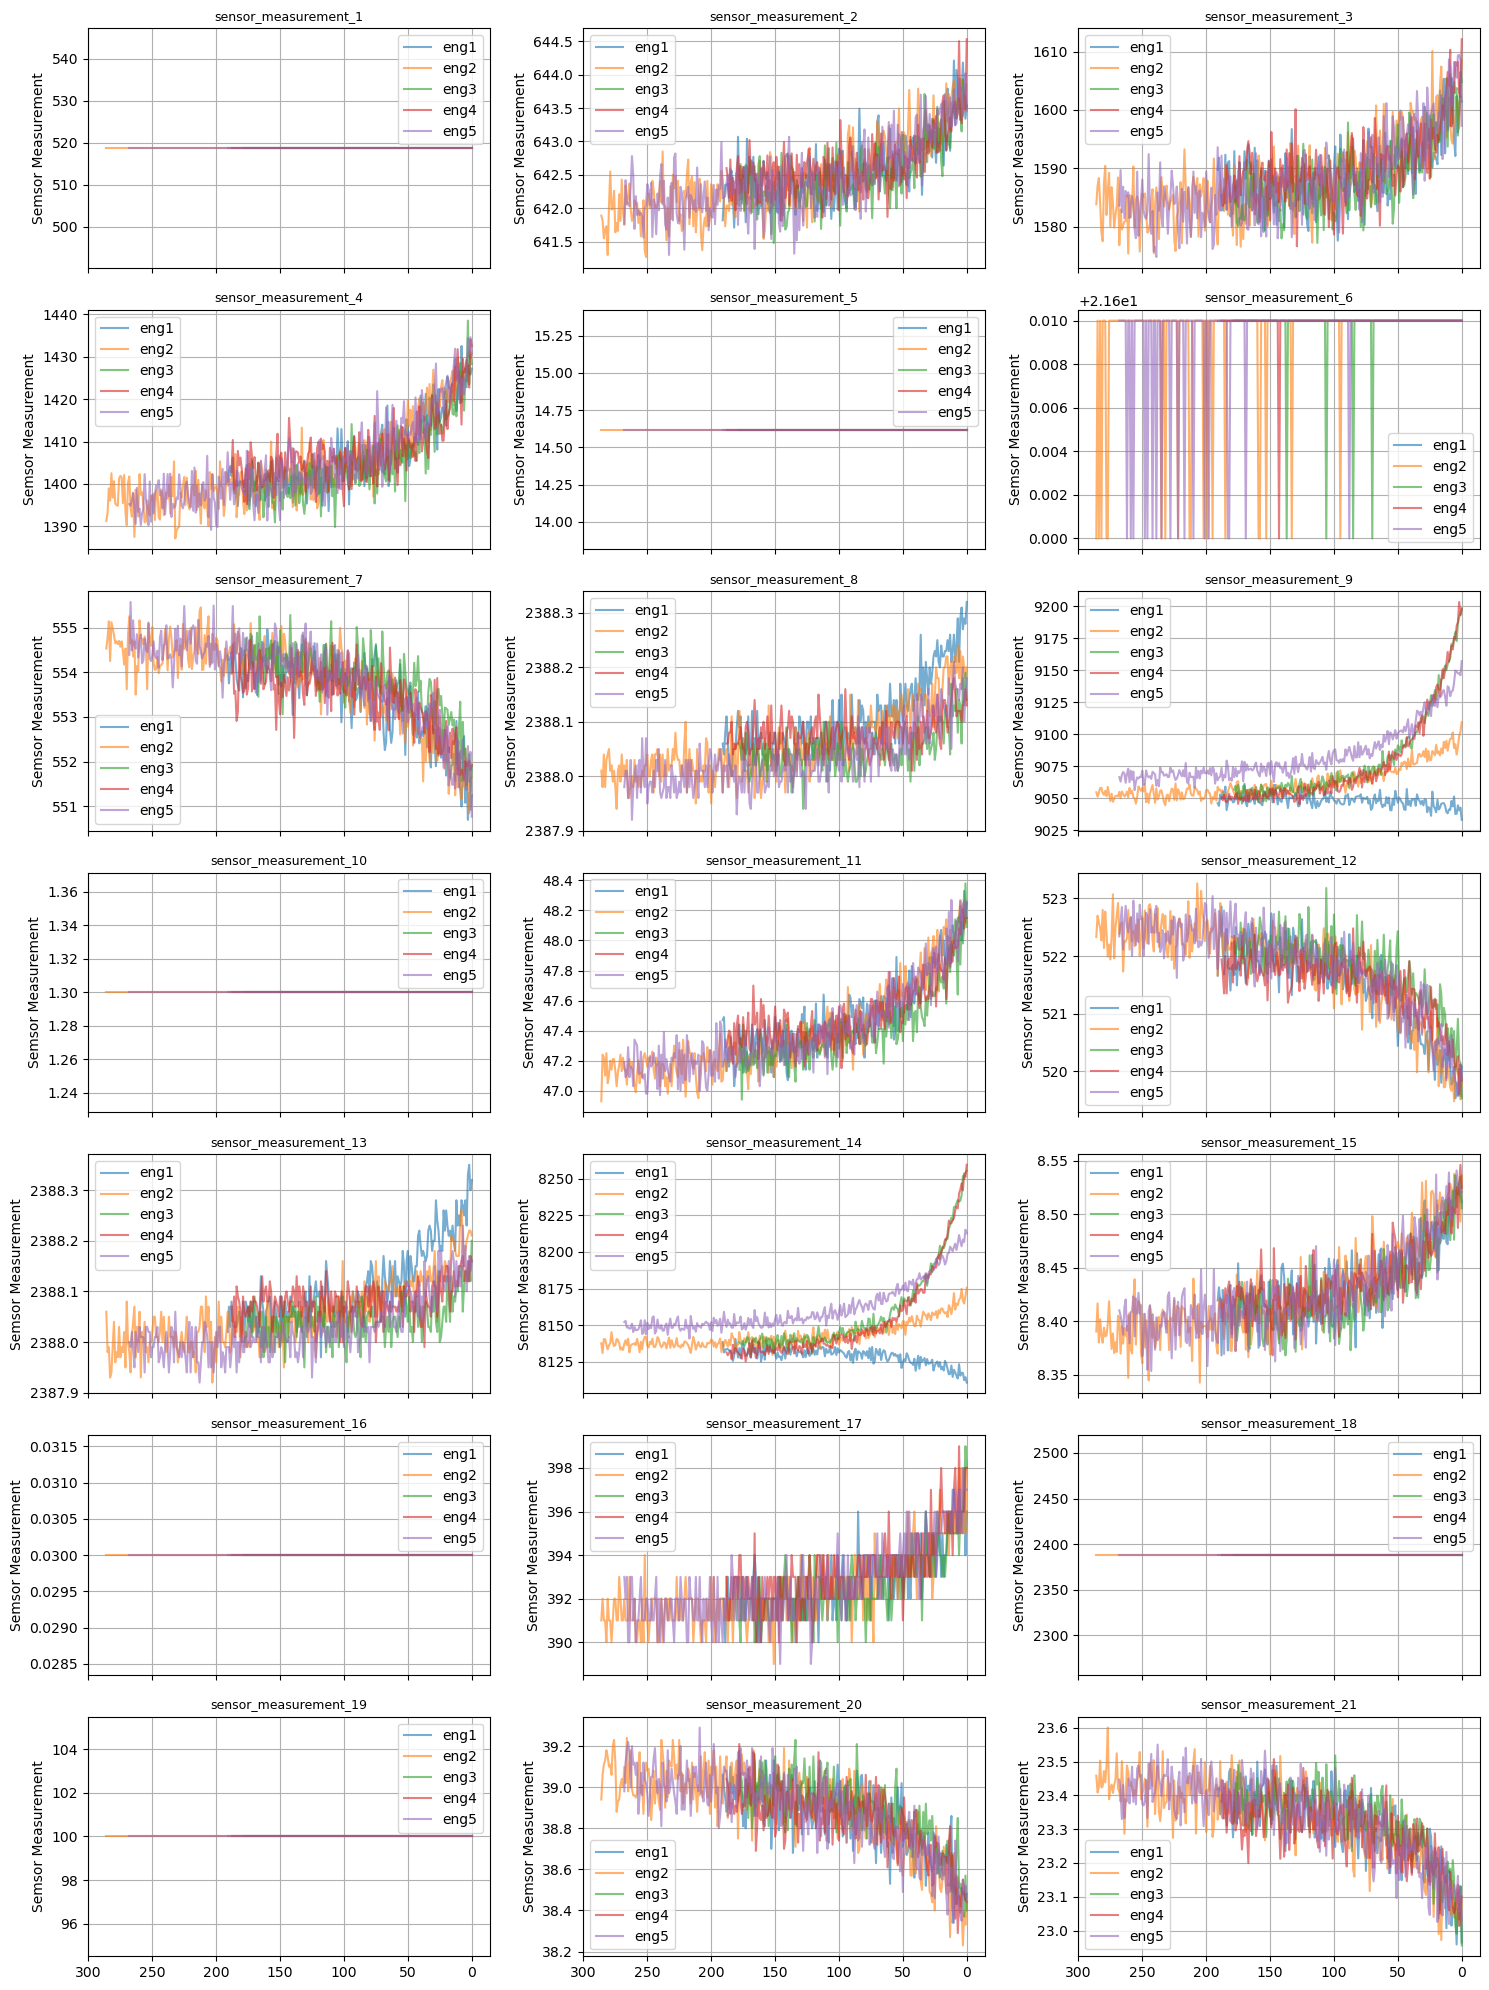

In [29]:
# Plot sensor_measurements agains RUL
#Independent sample of 5 engines
sample_units = train_001['unit_number'].unique()[:5]

fig, ax = plt.subplots(7, 3, figsize=(15, 20), sharex=True)
ax = ax.flatten()
for i, sensor in enumerate(sensor_measurements):
    for unit in sample_units:
        unit_df = train_001[train_001['unit_number']==unit]
        ax[i].plot(unit_df['RUL'], unit_df[sensor], label=f'eng{unit}', alpha=0.6)
    ax[i].set_ylabel('Semsor Measurement')
    ax[i].set_title(sensor, fontsize=9)
    ax[i].legend()
    ax[i].grid(True)
ax[0].invert_xaxis()
plt.tight_layout()
plt.savefig('sensorsvsrul.png')
plt.show();

In [22]:
# Check each sensors correlation with RUL
train_001[sensor_measurements + ['RUL']].corr()['RUL'].sort_values()

sensor_measurement_11   -0.696228
sensor_measurement_4    -0.678948
sensor_measurement_15   -0.642667
sensor_measurement_2    -0.606484
sensor_measurement_17   -0.606154
sensor_measurement_3    -0.584520
sensor_measurement_8    -0.563968
sensor_measurement_13   -0.562569
sensor_measurement_9    -0.390102
sensor_measurement_14   -0.306769
sensor_measurement_6    -0.128348
sensor_measurement_20    0.629428
sensor_measurement_21    0.635662
sensor_measurement_7     0.657223
sensor_measurement_12    0.671983
RUL                      1.000000
sensor_measurement_1          NaN
sensor_measurement_5          NaN
sensor_measurement_10         NaN
sensor_measurement_16         NaN
sensor_measurement_18         NaN
sensor_measurement_19         NaN
Name: RUL, dtype: float64

In [27]:
# Max cycle check for late-onset degradation sensors 9 and 14
# Compare max cycles of specific engines
train_001.groupby('unit_number')['time_in_cycles'].max().loc[[9,11, 12, 13, 14, 15]]

unit_number
9     201
11    240
12    170
13    163
14    180
15    207
Name: time_in_cycles, dtype: int64

In [28]:
train_001.tail()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21,max_cycle,RUL
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,200,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,200,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,200,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,200,1
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522,200,0


In [8]:
test_001 = pd.read_csv('test_FD001.txt', sep=r'\s+', header=None)
test_001.shape

(13096, 26)

In [11]:
RUL_001 = pd.read_csv('RUL_FD001.txt', sep='\t', header=None)
RUL_001

,0
0,112
1,98
2,69
3,82
4,91
...,...
95,137
96,82
97,59
98,117
